In [1]:
from cryosim.atom import atomic_potentials
import torch
from cryosim.array_utils import radial_grid_3d, radial_profile_3d
import matplotlib.pyplot as plt
from cryosim.plotting_tools import plot3d
from cryosim.fft_tools import fftn
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from cryosim.potential import PotentialBuilder, GemmiPotentialBuilder
import mrcfile
from cryosim.pdbtools import PDB
import gemmi
import numpy as np
from cryosim.atom import atom_number
import json

%load_ext autoreload
%autoreload 2

In [2]:
# Path to your JSON file
file_path = "/mnt/cbis/home/e0788253/sffit/json/params_cat.json"

# Open and read the JSON file
with open(file_path, "r") as f:
    data = json.load(f)

# Now `data` is a Python dictionary (or list, depending on the JSON)
print(data["O(HH)"])

{'coefficients': [{'a': 0.3131, 'b': 0.8722}, {'a': 0.8102, 'b': 4.9669}, {'a': 0.9812, 'b': 14.1666}, {'a': -0.5997, 'b': 64.1638}, {'a': -0.1519, 'b': 121.3711}], 'function': {'frequency': [0.011199999692421277, 0.023599999077263827, 0.03599999846210638, 0.04839999784694893, 0.06079999723179148, 0.07319999661663404, 0.08559999600147658, 0.09799999538631912, 0.11039999477116169, 0.12279999415600423, 0.13519999354084677, 0.14759999292568932, 0.1599999923105319, 0.17239999169537445, 0.184799991080217, 0.19719999046505954, 0.20959998984990208, 0.22199998923474468, 0.23439998861958722, 0.24679998800442973, 0.2591999873892723, 0.2715999867741149, 0.2839999861589574, 0.2963999855438, 0.30879998492864247, 0.32119998431348507, 0.33359998369832766, 0.34599998308317015, 0.3583999824680127, 0.37079998185285523, 0.38319998123769783, 0.3955999806225404, 0.4079999800073829, 0.42039997939222545, 0.432799978777068, 0.4451999781619106, 0.4575999775467532, 0.4699999769315957, 0.4823999763164382, 0.4947

In [3]:
data["O(HH)"]["coefficients"]

[{'a': 0.3131, 'b': 0.8722},
 {'a': 0.8102, 'b': 4.9669},
 {'a': 0.9812, 'b': 14.1666},
 {'a': -0.5997, 'b': 64.1638},
 {'a': -0.1519, 'b': 121.3711}]

## Simulated by Shryov

In [4]:
mmcif_filepath = "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# mmcif_filepath = '/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8sgv_sim_1_cat_params.cif'
# mmcif_filepath = '/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/9bdj_sim_1_cat_params.cif'
# mmcif_filepath = '/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1.pdb'

In [5]:
mrc_filepath = "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_tabulated.mrc"
# mrc_filepath = '/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/9bdj_sim_1_tabulated.mrc'
with mrcfile.open(mrc_filepath) as mrc:
    print(mrc.header)
    precomputed = torch.as_tensor(mrc.data)
precomputed.shape

(250, 250, 250, 2, 0, 0, 0, 250, 250, 250, (200.0, 200.0, 200.0), (90.0, 90.0, 90.0), 1, 2, 3, -0.23055442, 1.5780983, 0.0057278285, 1, 0, b'\x00\x00\x00\x00\x00\x00\x00\x00', b'CCP4', 20140, b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00', (0.0, 0.0, 0.0), b'MAP ', [68, 65,  0,  0], 0.062436752, 1, [b'written by GEMMI                                                                ', b'                                                                                ', b'                                                                                ', b'                                                                                ', b'                                                                

/tmp/ipykernel_3306129/2510770679.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  precomputed = torch.as_tensor(mrc.data)


torch.Size([250, 250, 250])

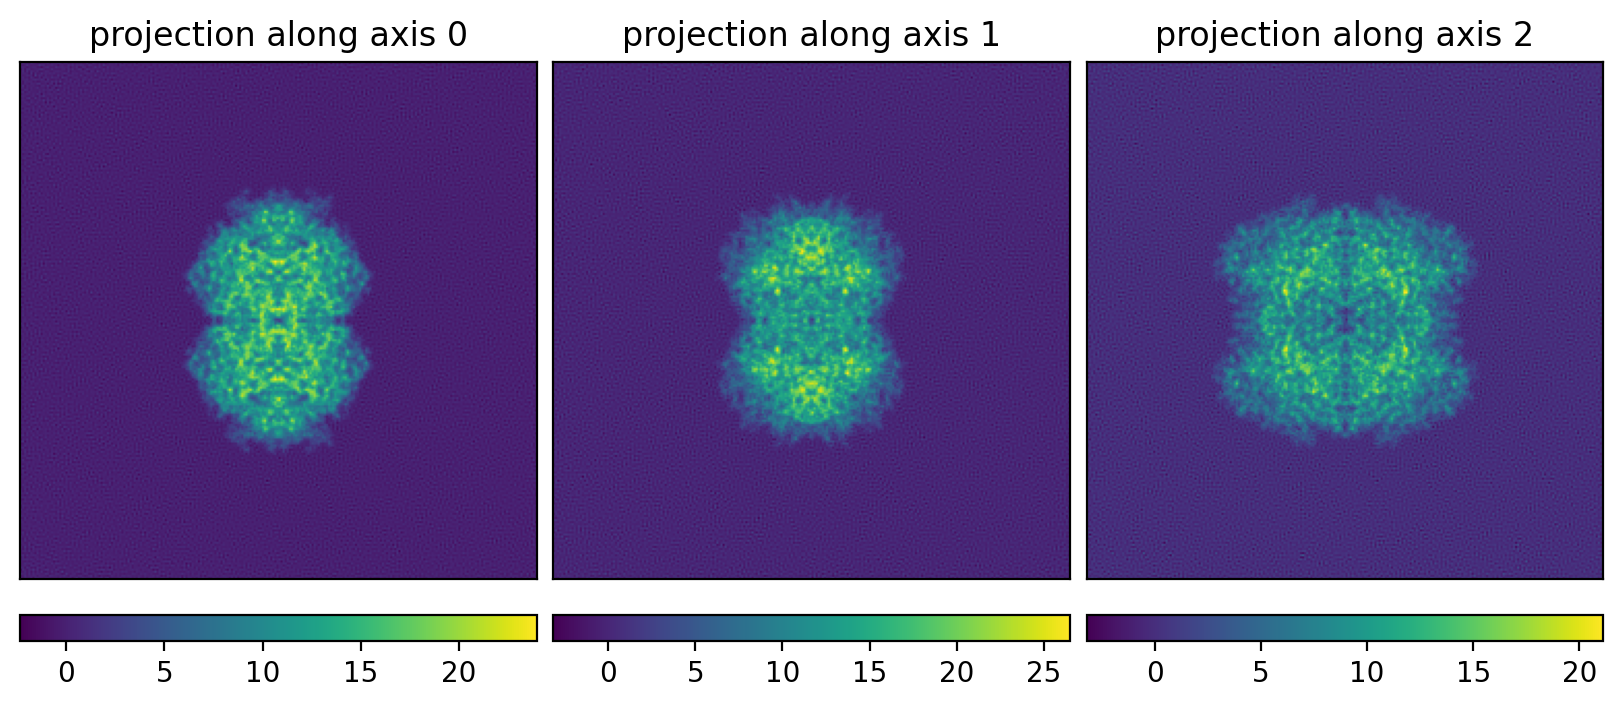

In [6]:
plot3d(precomputed)

## GPB Class

In [97]:
n = 250
dx = 0.8
gpb = GemmiPotentialBuilder(n, dx)

In [98]:
from_gemmi = gpb.build_potential_from_custom_mmcif(mmcif_filepath)

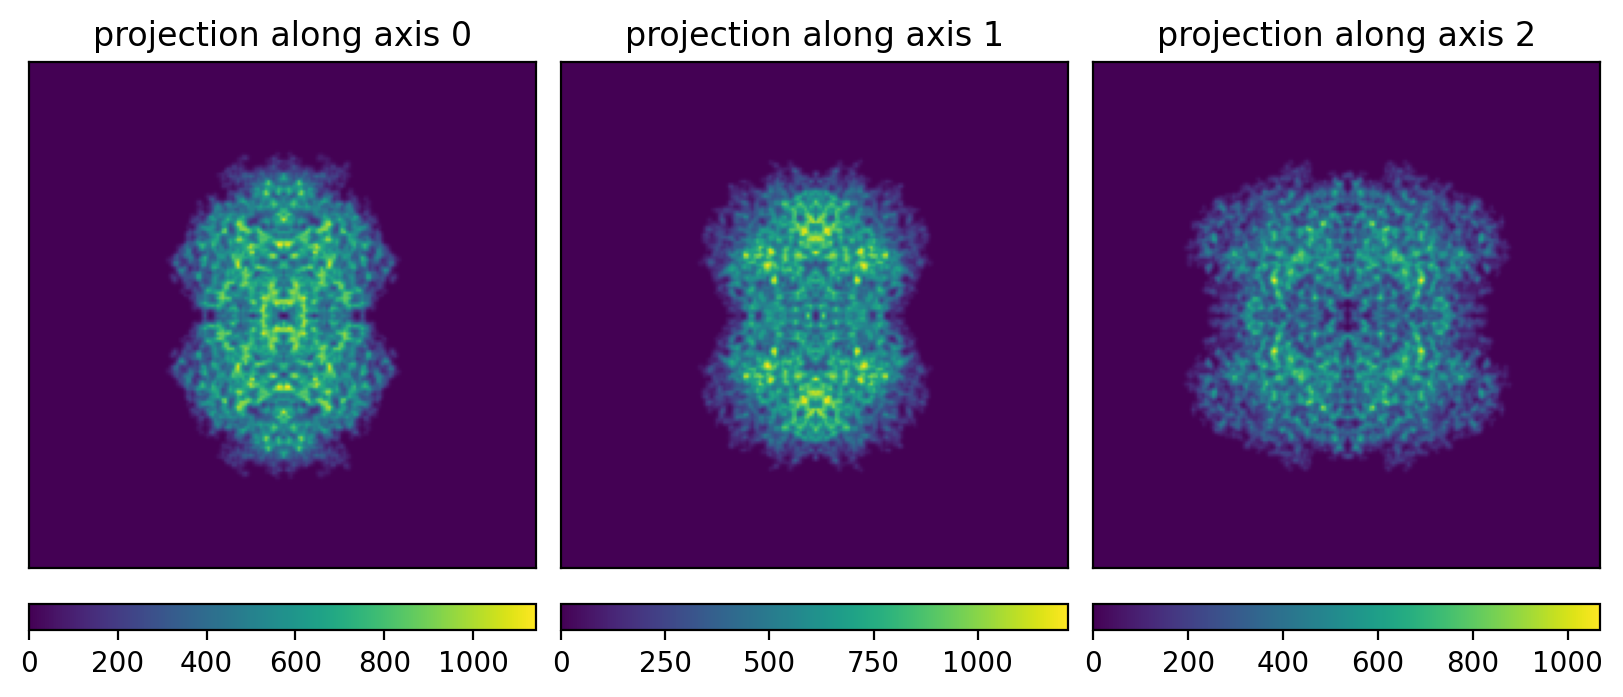

In [93]:
plot3d(from_gemmi)

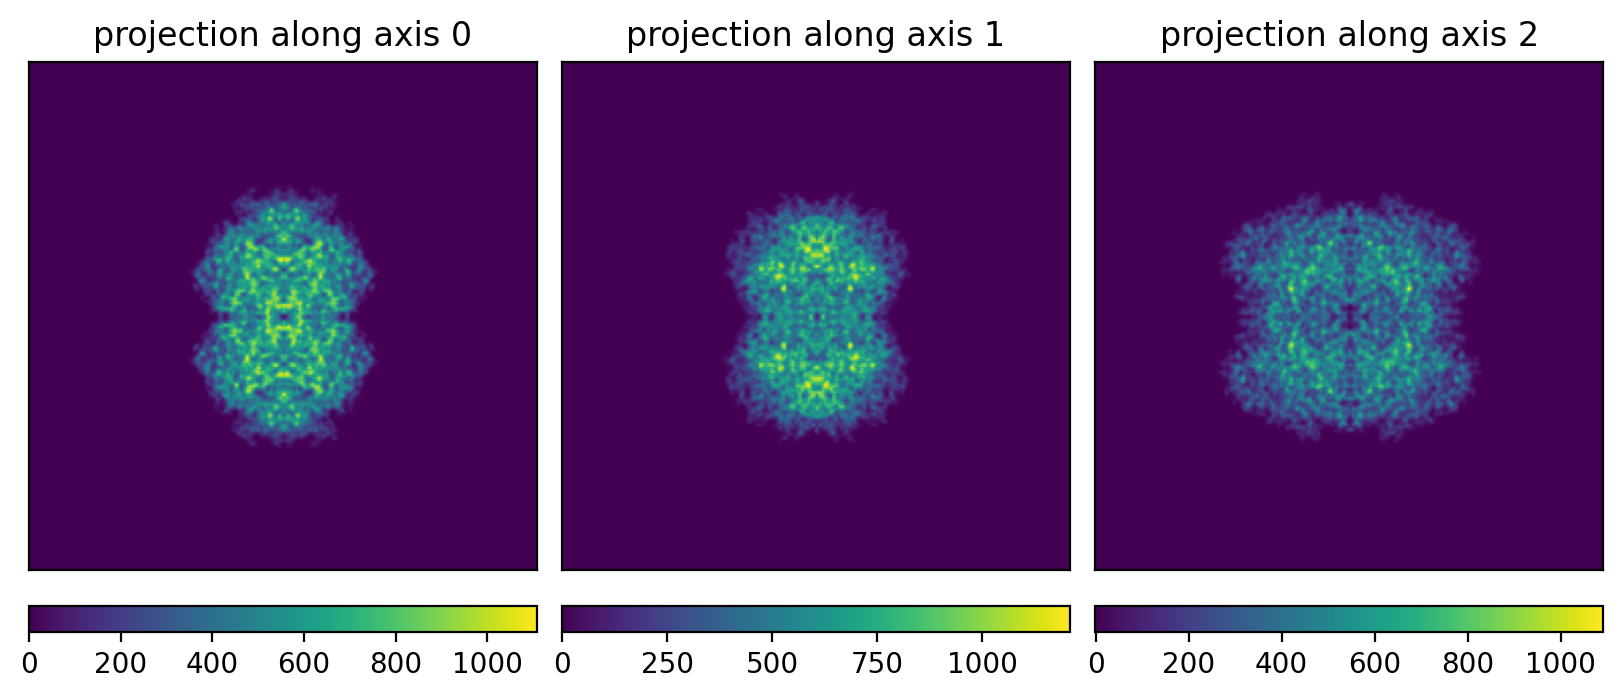

In [99]:
plot3d(from_gemmi)


## My own gemmi

In [30]:
# 1. Read the CIF structure file
st = gemmi.read_structure(mmcif_filepath)

# 2. Create a DensityCalculator for electron scattering
# dencalc = gemmi.DensityCalculatorE()
block = gemmi.cif.read_file(mmcif_filepath).sole_block()

# read SF coefficients
ctable = block.find(
    "_lmb_scat_coef.",
    [
        "coef_a1",
        "coef_a2",
        "coef_a3",
        "coef_a4",
        "coef_a5",
        "coef_b1",
        "coef_b2",
        "coef_b3",
        "coef_b4",
        "coef_b5",
    ],
)

coefs = np.empty((len(ctable), 10))
for ind, row in enumerate(ctable):
    coefs[ind] = [float(field) for field in row]

max_serial = max(cra.atom.serial for cra in st[0].all())
custom_form_factors = np.zeros((max_serial + 1, 10))
itable = block.find("_atom_site.", ["id", "scat_id"])
for row in itable:
    serial, scat_id = row
    custom_form_factors[int(serial)] = coefs[int(scat_id)]

gemmi.set_custom_form_factors(custom_form_factors)
dencalc = gemmi.DensityCalculatorC()

# 3. Set up grid parameters first
pixel_size = 0.8  # Angstroms
num_pixels = 300
box_size = num_pixels * pixel_size  # 200 Angstroms

# 4. Create unit cell for the grid
unit_cell = gemmi.UnitCell(box_size, box_size, box_size, 90, 90, 90)

# 5. Initialize the grid through the density calculator
dencalc.set_refmac_compatible_blur(st[0])  # st[0] is the Model, not Structure
dencalc.grid.unit_cell = unit_cell
dencalc.grid.spacegroup = gemmi.SpaceGroup("P1")

# 6. Set explicit grid dimensions
dencalc.grid.set_size(num_pixels, num_pixels, num_pixels)

# 7. Calculate the scattering potential
dencalc.put_model_density_on_grid(st[0])

# 8. Access the resulting 3D grid
potential3d = np.array(dencalc.grid, copy=False)
print(f"Grid shape: {potential3d.shape}")
print(
    f"Unit cell: {dencalc.grid.unit_cell.a:.2f} x {dencalc.grid.unit_cell.b:.2f} x {dencalc.grid.unit_cell.c:.2f} Å"
)
print(f"Pixel size: {dencalc.grid.unit_cell.a / dencalc.grid.nu:.2f} Å")

Grid shape: (300, 300, 300)
Unit cell: 240.00 x 240.00 x 240.00 Å
Pixel size: 0.80 Å


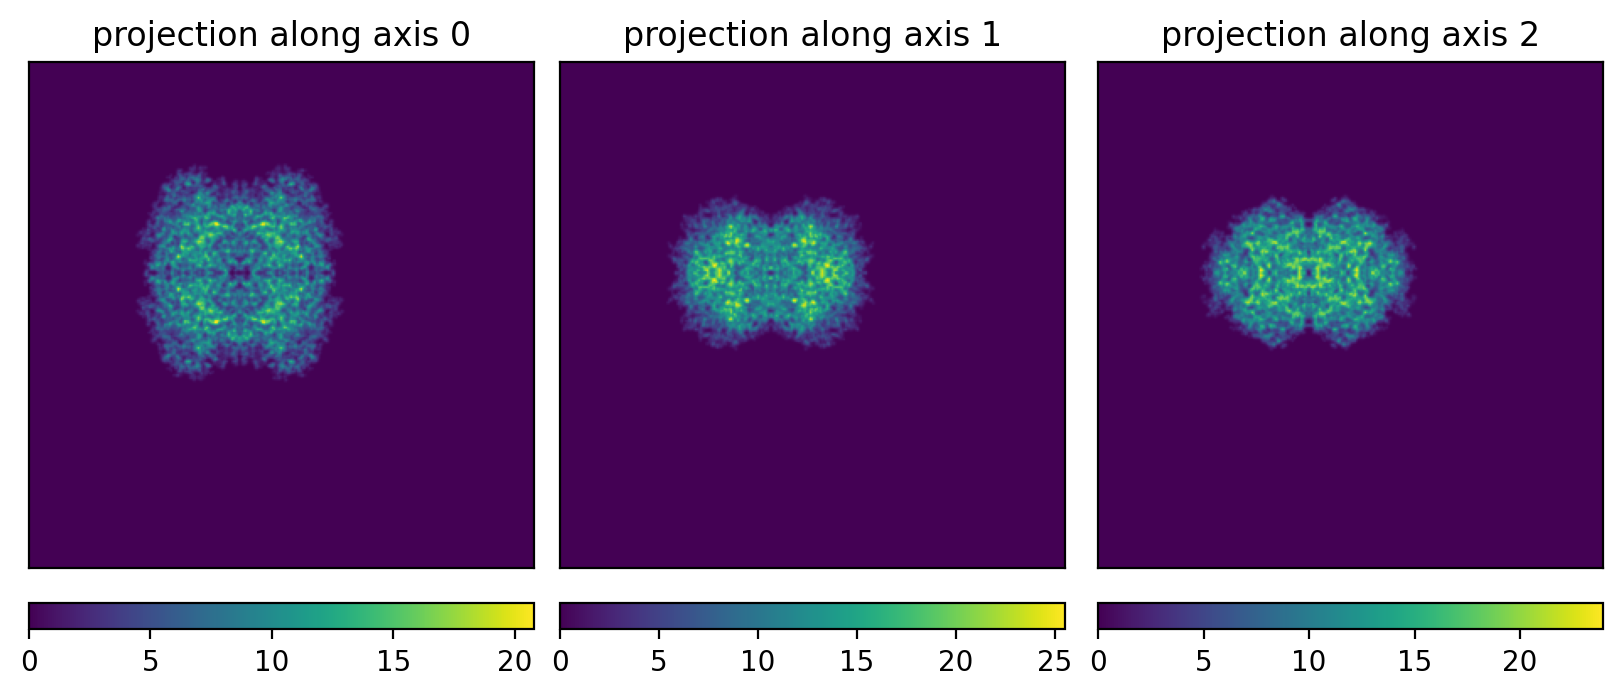

In [31]:
plot3d(potential3d)

## My simulation

In [100]:
cif_dict = MMCIF2Dict(mmcif_filepath)

In [101]:
scat_ids = cif_dict["_atom_site.scat_id"]
scat_ids = torch.tensor([int(x) for x in scat_ids])
elem_ids = cif_dict["_atom_site.type_symbol"]
elem_ids = atom_number(elem_ids)

In [102]:
x_coords = cif_dict["_atom_site.Cartn_x"]
x_coords = torch.tensor([float(x) for x in x_coords])

y_coords = cif_dict["_atom_site.Cartn_y"]
y_coords = torch.tensor([float(x) for x in y_coords])

z_coords = cif_dict["_atom_site.Cartn_z"]
z_coords = torch.tensor([float(x) for x in z_coords])

In [103]:
coords = torch.stack((x_coords, y_coords, z_coords), dim=1)
coords = PDB.center_coordinates(coords)

In [104]:
pb_kirkland = PotentialBuilder(250, 0.8, elem_ids, parameterization="kirkland")
pb_lobato = PotentialBuilder(250, 0.8, elem_ids, parameterization="lobato")
pb_shryov = PotentialBuilder(
    250, 0.8, scat_ids, parameterization="shryov", mmcif_filepath=mmcif_filepath
)

Parsing MMCIF file.
Number of unique 'atoms': 30


In [105]:
with torch.no_grad():
    lobato = pb_lobato(coords, method="3d")
    kirkland = pb_kirkland(coords, method="2d")
    shryov = pb_shryov(coords)

Output()

Output()

Output()

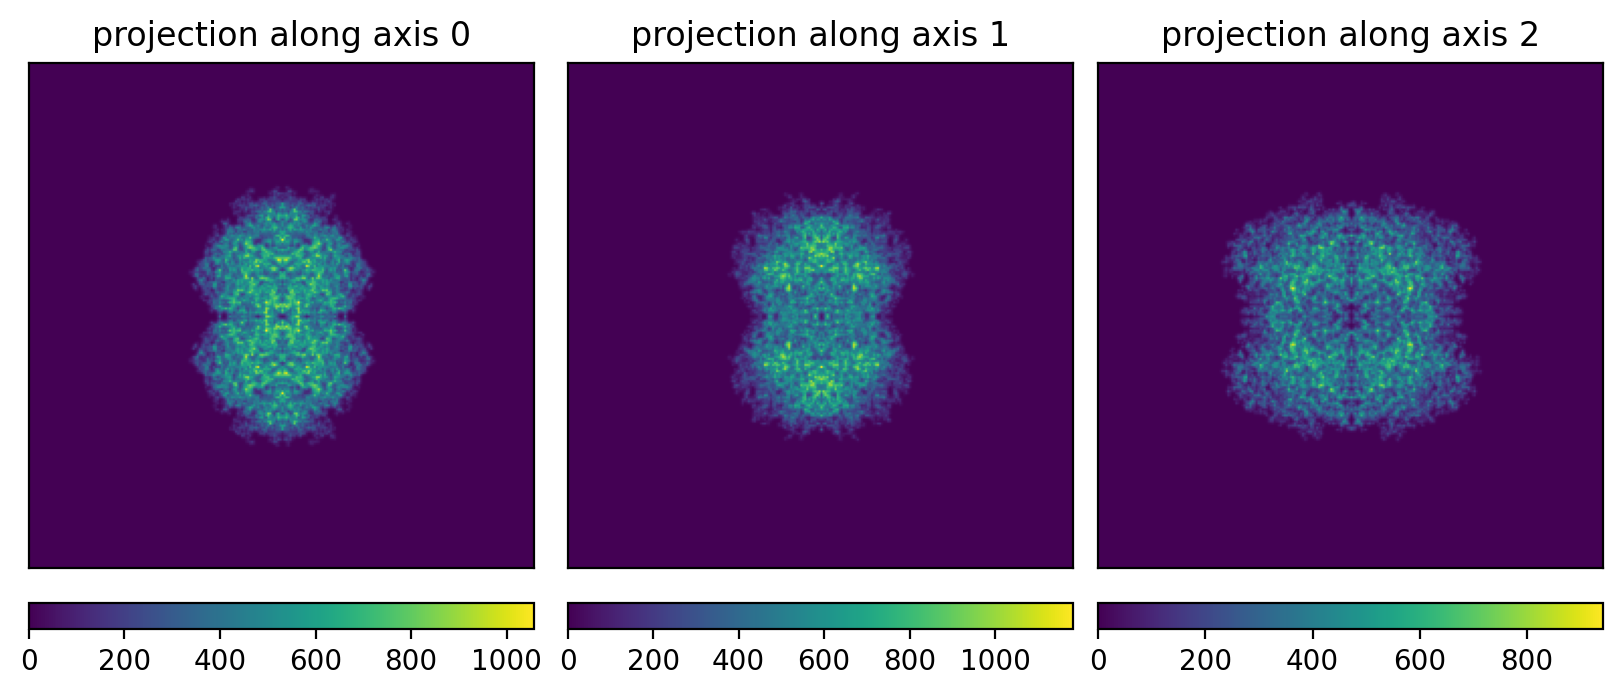

In [106]:
plot3d(lobato)

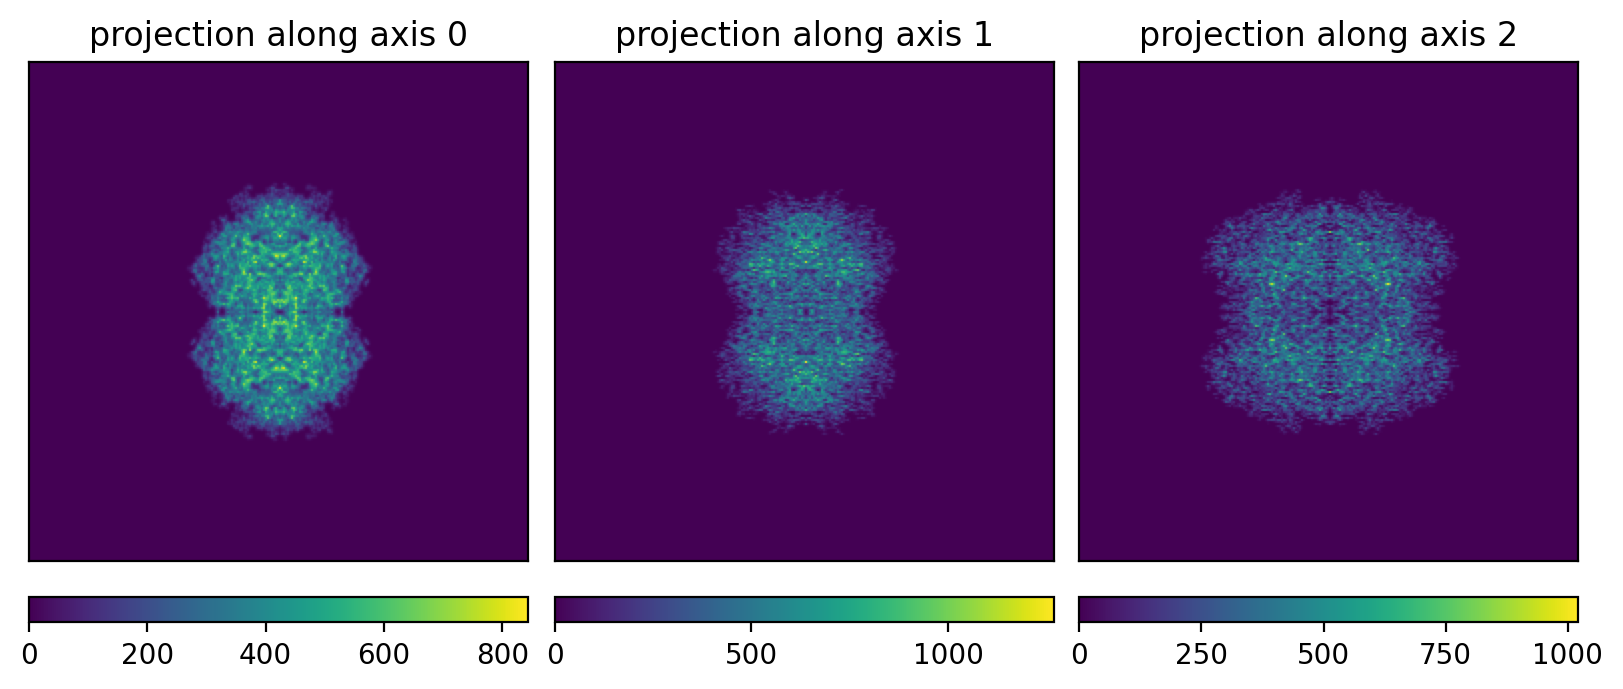

In [107]:
plot3d(kirkland)

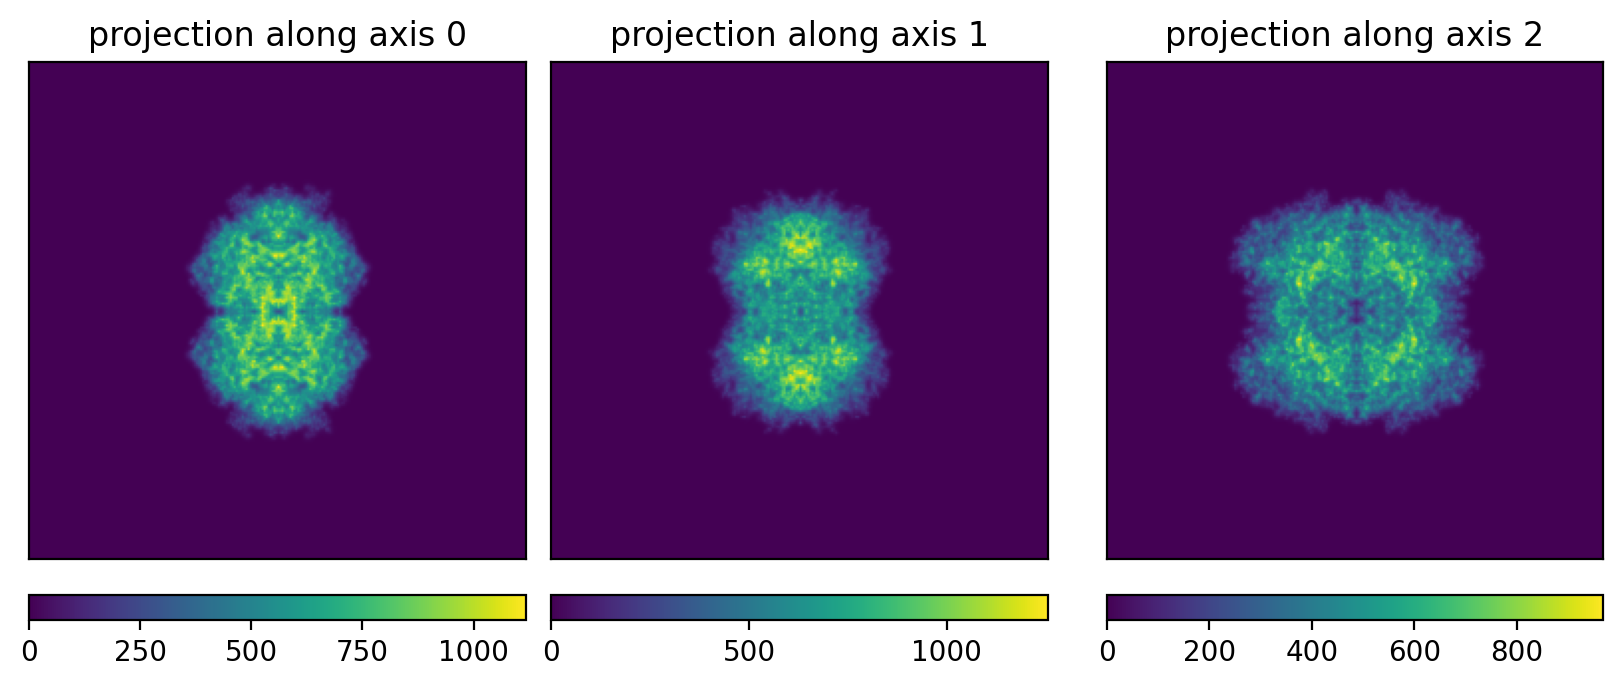

In [108]:
plot3d(shryov)

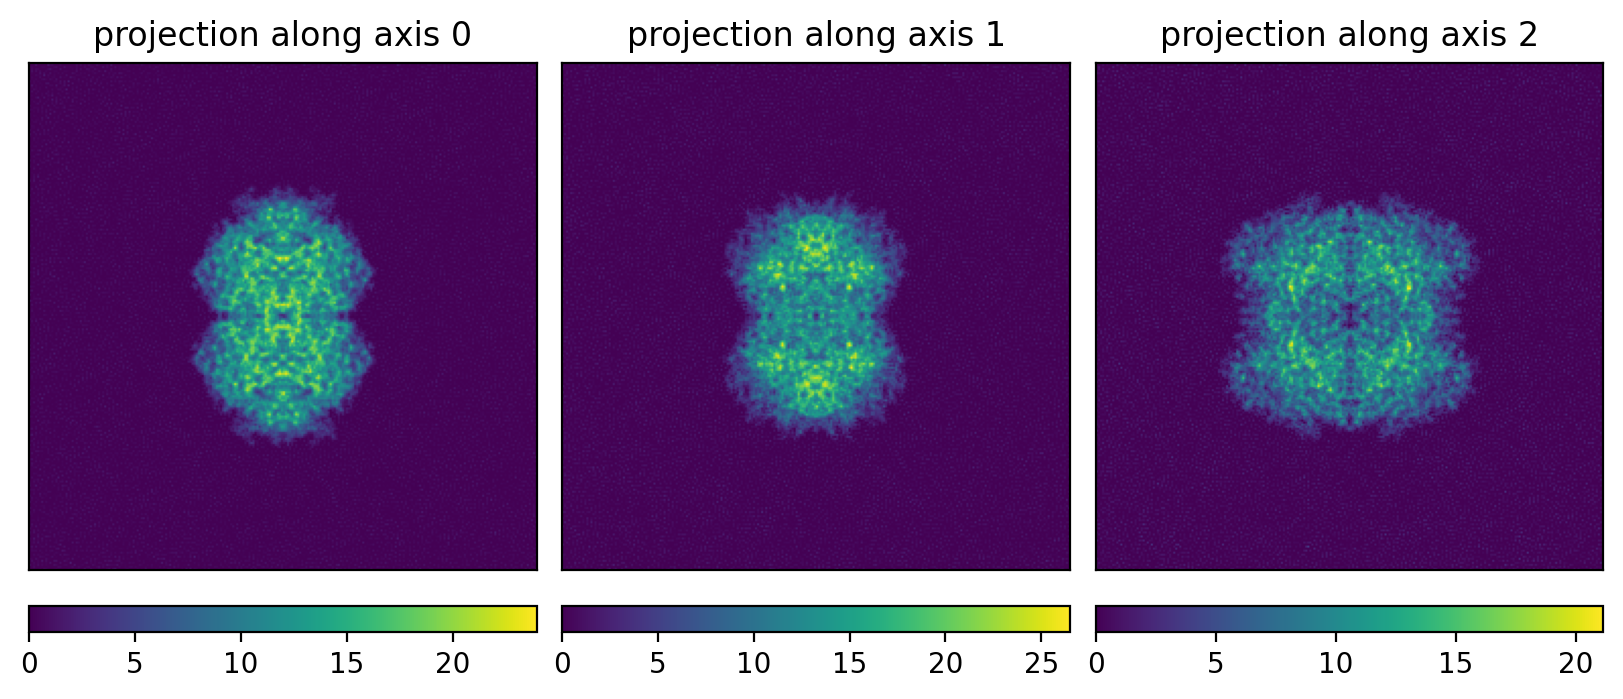

In [109]:
plot3d(precomputed, vmin=0)

## Test Gemmi Potential builder

In [22]:
gpb = GemmiPotentialBuilder(250, 0.8)
gemmi = gpb.build_potential(coords, elem_ids)

In [23]:
gemmi_par = gpb.build_potential(coords, elem_ids, n_processes=None)

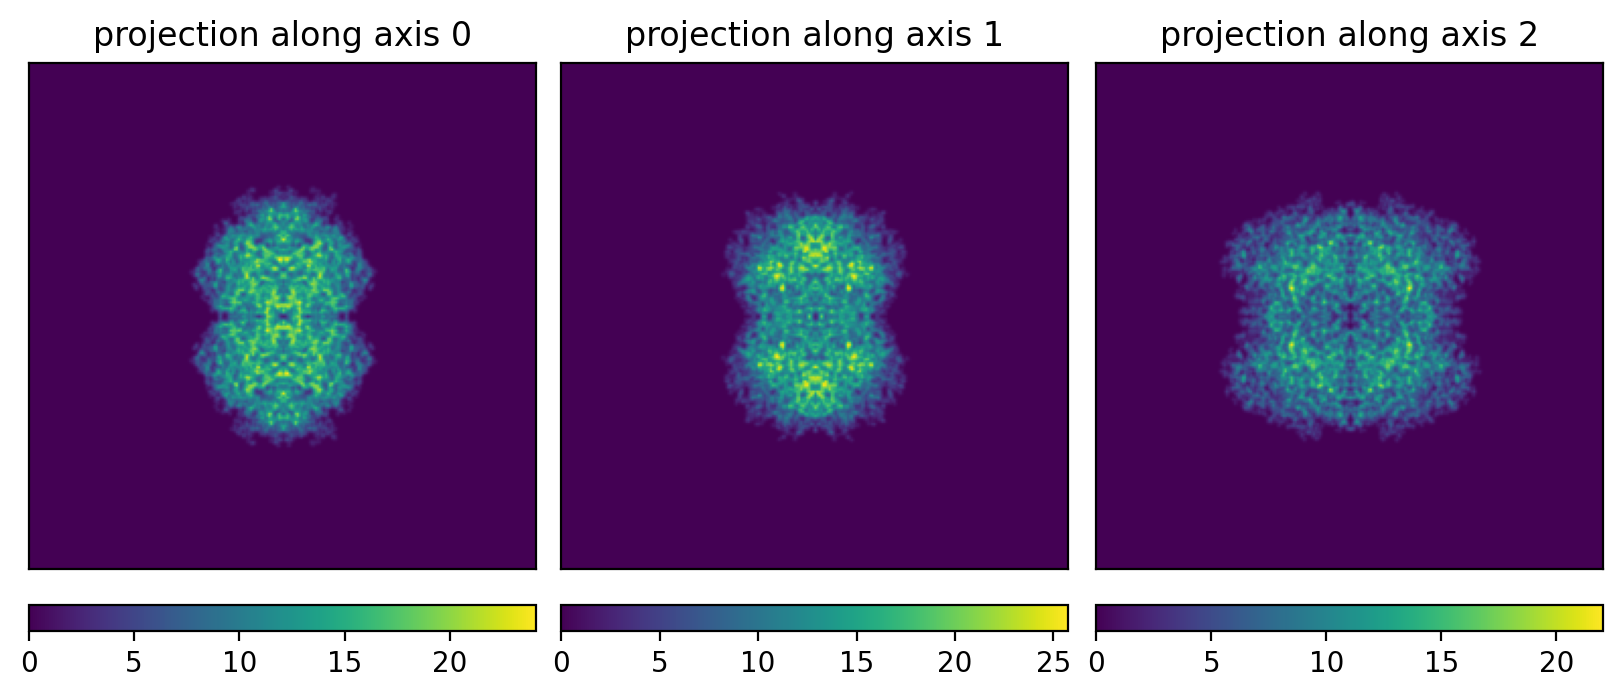

In [24]:
plot3d(gemmi, vmin=0)

In [ ]:
plot3d(gemmi_par, vmin=0)

In [52]:
cif_dict.keys()

dict_keys(['data_', '_entry.id', '_pdbx_database_status.entry_id', '_pdbx_database_status.recvd_initial_deposition_date', '_cell.entry_id', '_cell.length_a', '_cell.length_b', '_cell.length_c', '_cell.angle_alpha', '_cell.angle_beta', '_cell.angle_gamma', '_symmetry.entry_id', '_symmetry.space_group_name_H-M', '_symmetry.Int_Tables_number', '_entity.id', '_entity.type', '_entity_poly.entity_id', '_entity_poly.type', '_entity_poly.pdbx_strand_id', '_entity_poly.pdbx_seq_one_letter_code', '_struct_ref.id', '_struct_ref.entity_id', '_struct_ref.db_name', '_struct_ref.db_code', '_struct_ref.pdbx_db_accession', '_struct_ref.pdbx_db_isoform', '_struct_ref_seq.align_id', '_struct_ref_seq.ref_id', '_struct_ref_seq.pdbx_strand_id', '_struct_ref_seq.seq_align_beg', '_struct_ref_seq.seq_align_end', '_struct_ref_seq.db_align_beg', '_struct_ref_seq.db_align_end', '_struct_ref_seq.pdbx_auth_seq_align_beg', '_struct_ref_seq.pdbx_seq_align_beg_ins_code', '_struct_ref_seq.pdbx_auth_seq_align_end', '_st

In [56]:
len(cif_dict["_atom_site.scat_id"]), len(cif_dict["_atom_site.id"])

(30982, 30982)

In [379]:
n = 200
x = torch.linspace(-2.5, 2.5, n)
dx = x[1] - x[0]
k = torch.fft.fftfreq(n, dx)
dk = k[1] - k[0]
R = radial_grid_3d(n, float(dx), convention="torch")
K = radial_grid_3d(n, float(dk), convention="torch")

a0 = 0.529  # Bohr radius, Angstrom
e = 14.4  # electron charge, V-Angstrom

In [380]:
element = 16
kirkland = atomic_potentials.kirkland_atomic_potential_3d(element, R)
kirkland_f = atomic_potentials.kirkland_atomic_potential_3d_fourier(element, K)
kirkland_from_f = 2 * torch.pi * a0 * e * torch.abs(fftn(kirkland_f)) * dk**3
lobato = atomic_potentials.lobato_atomic_potential_3d(element, R)
lobato_f = atomic_potentials.lobato_atomic_potential_3d_fourier(element, K)
lobato_from_f = 2 * torch.pi * a0 * e * torch.abs(fftn(lobato_f)) * dk**3

In [391]:
element = 20
a0 = 0.529  # Bohr radius, [Angstrom]
e = 14.4  # electron charge, [V-Angstrom]
c1 = 2 * torch.pi * e * a0
shryov_f = atomic_potentials.shryov_atomic_potential_3d_fourier(
    element, K, "/mnt/cbis/home/e0788253/sffit/tests/data/8el9_with_sf.cif"
)
shryov = atomic_potentials.shryov_atomic_potential_3d(
    element, R, "/mnt/cbis/home/e0788253/sffit/tests/data/8el9_with_sf.cif"
)

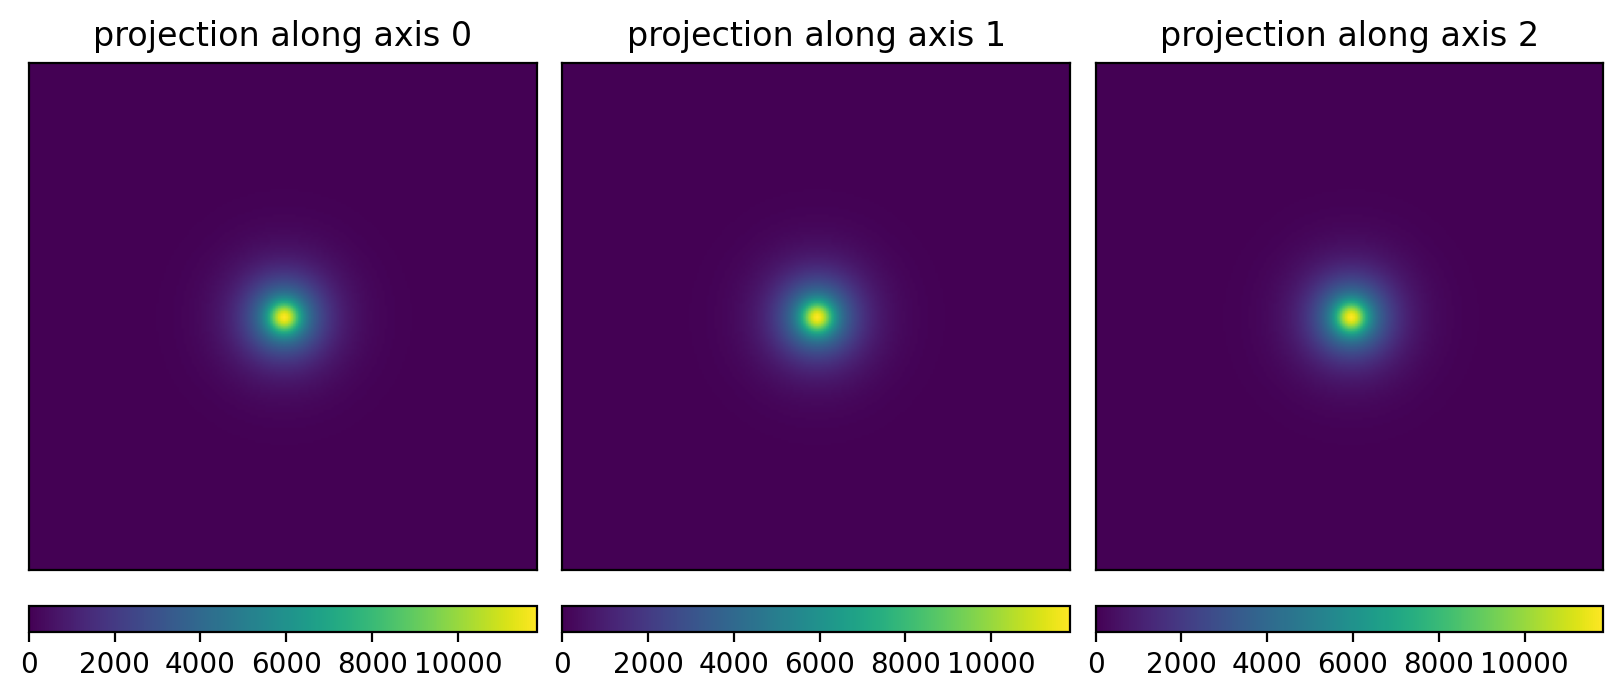

In [392]:
plot3d(torch.abs(fftn(shryov_f)) * c1 * dk**3)

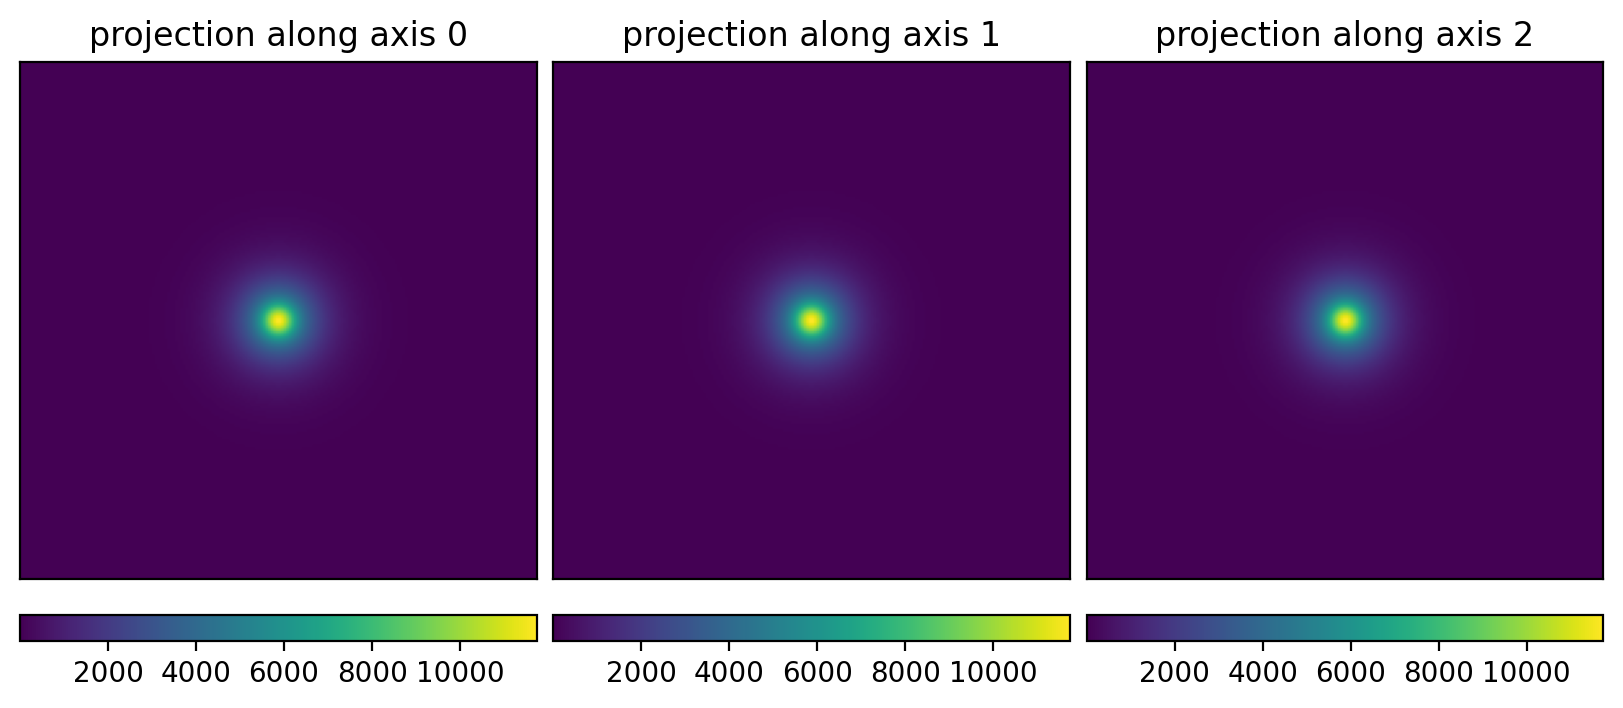

In [389]:
plot3d(shryov)

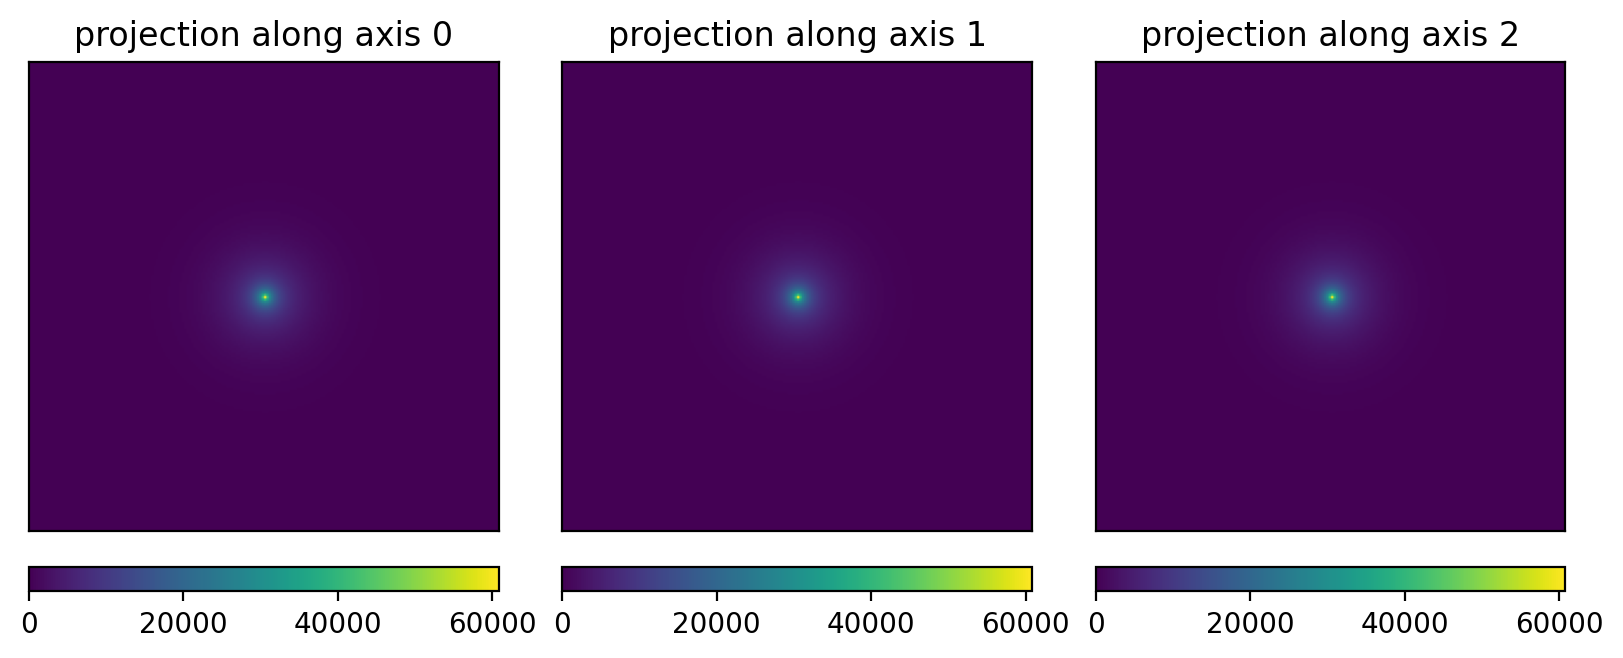

In [384]:
plot3d(kirkland_from_f)

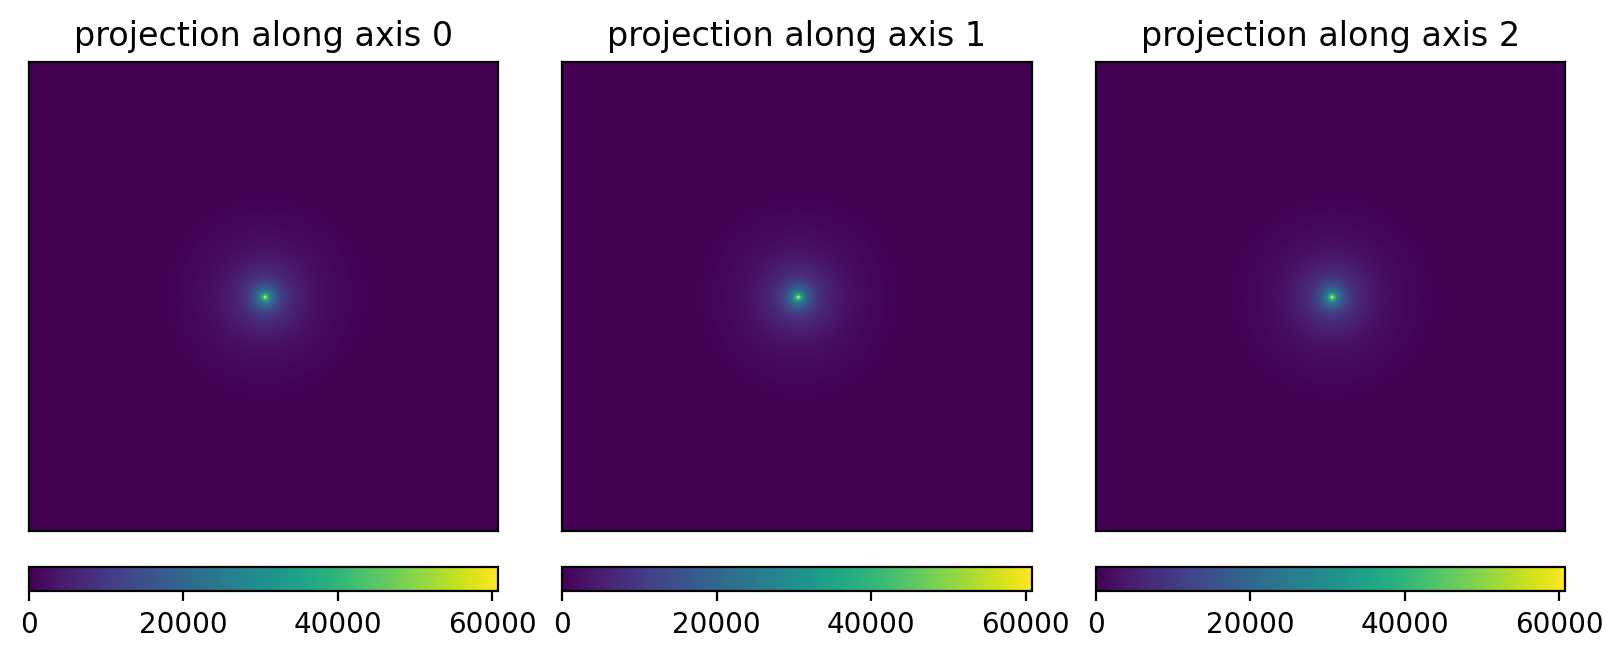

In [385]:
plot3d(lobato_from_f)

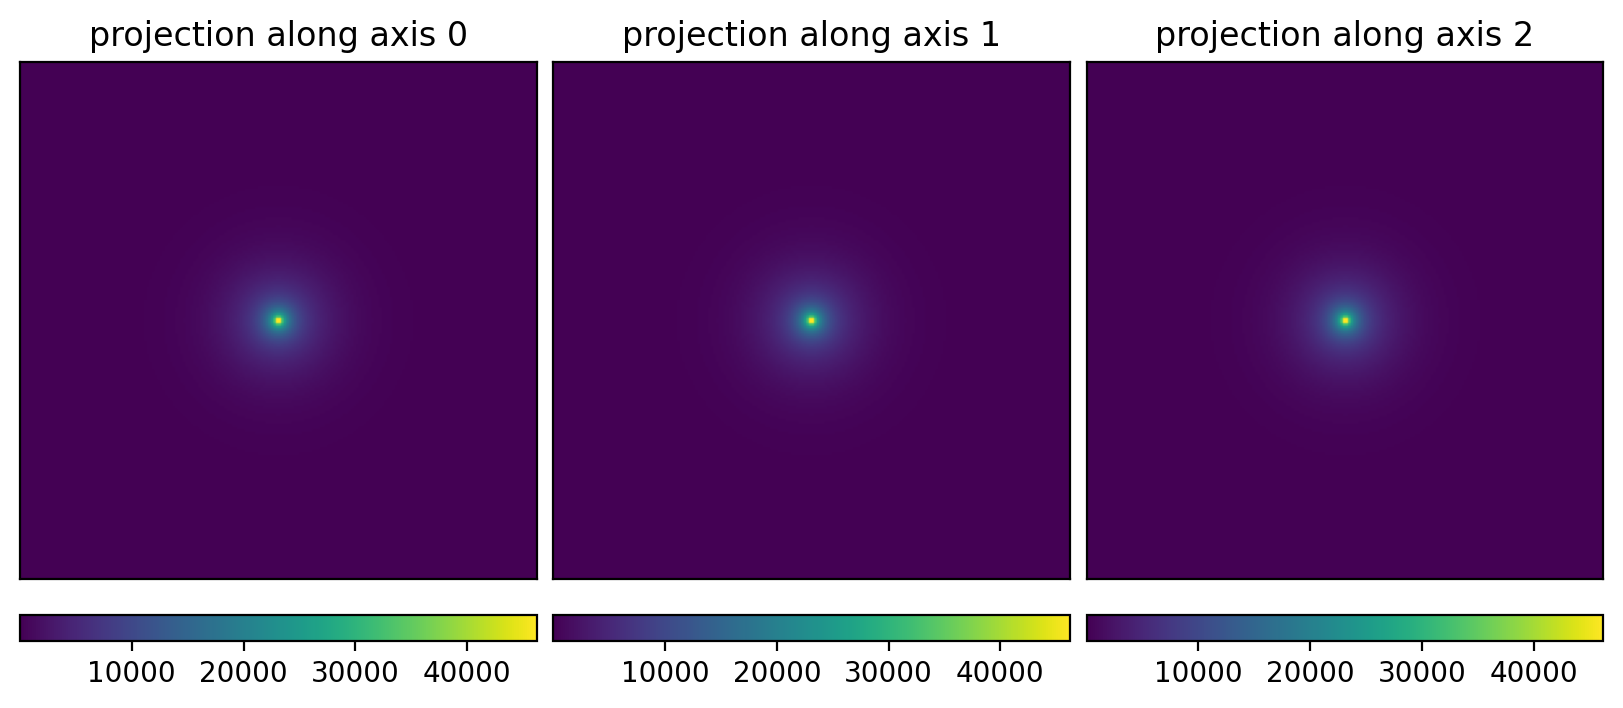

In [386]:
plot3d(kirkland)

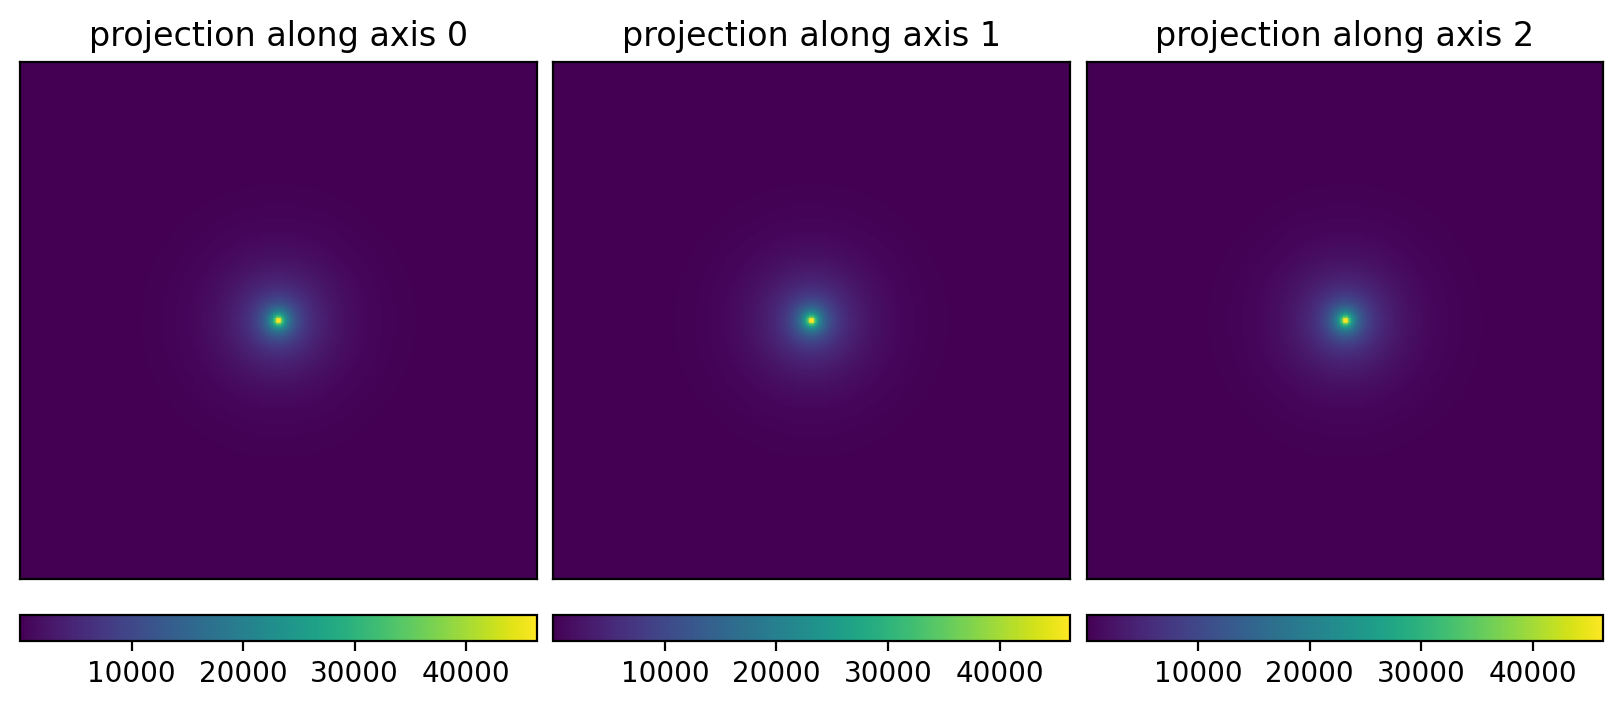

In [387]:
plot3d(lobato)

## Single atom

In [79]:
n = 256  # number of pixels per axis
dx = 0.025  # angstrom, pixel size.
k = torch.fft.fftfreq(n, dx)
dk = k[1] - k[0]
device = "cpu"
coords = torch.tensor([0, 0, 0]).reshape(-1, 3)
mmcif_filepath = "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
pdb = PDB(mmcif_filepath)
pb = PotentialBuilder(
    n,
    dx,
    # pdb.atomic_numbers[0].reshape(1, 1),
    torch.tensor([20]).reshape(1, 1),
    parameterization="shtyrov",
    mmcif_filepath=mmcif_filepath,
).to(device)
gpb = GemmiPotentialBuilder(n, dx, pdb.atomic_numbers[0].reshape(1, 1), b_factor=0.0)

Output()

In [80]:
pdb.atomic_numbers[0]

tensor(7)

In [81]:
with torch.no_grad():
    V = pb(coords).clone()
    V_gemmi_custom = gpb.build_potential_from_custom_mmcif(mmcif_filepath).clone()
    V_gemmi = gpb.build_potential(torch.tensor([[0, 0, 0]])).clone()

Output()

20


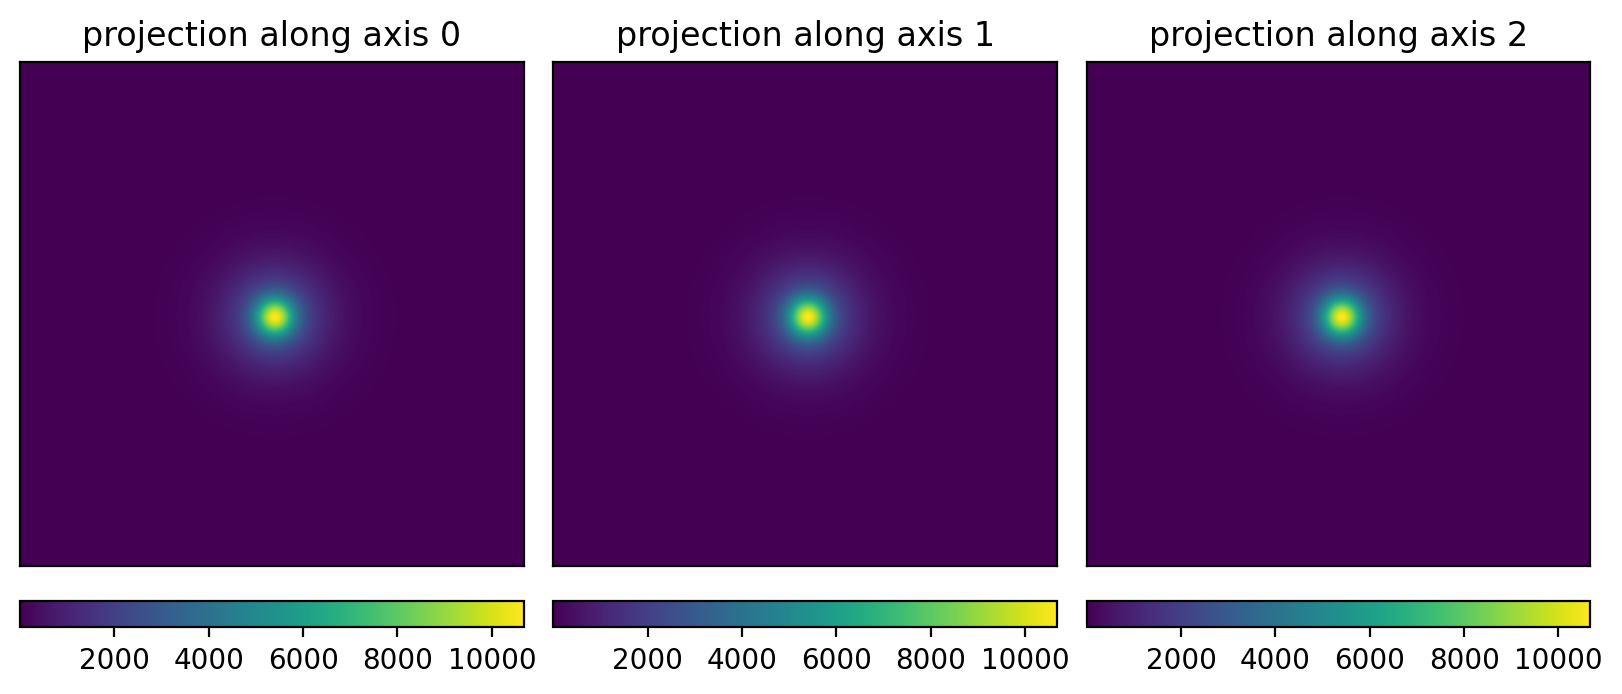

In [82]:
plot3d(torch.abs((V)))

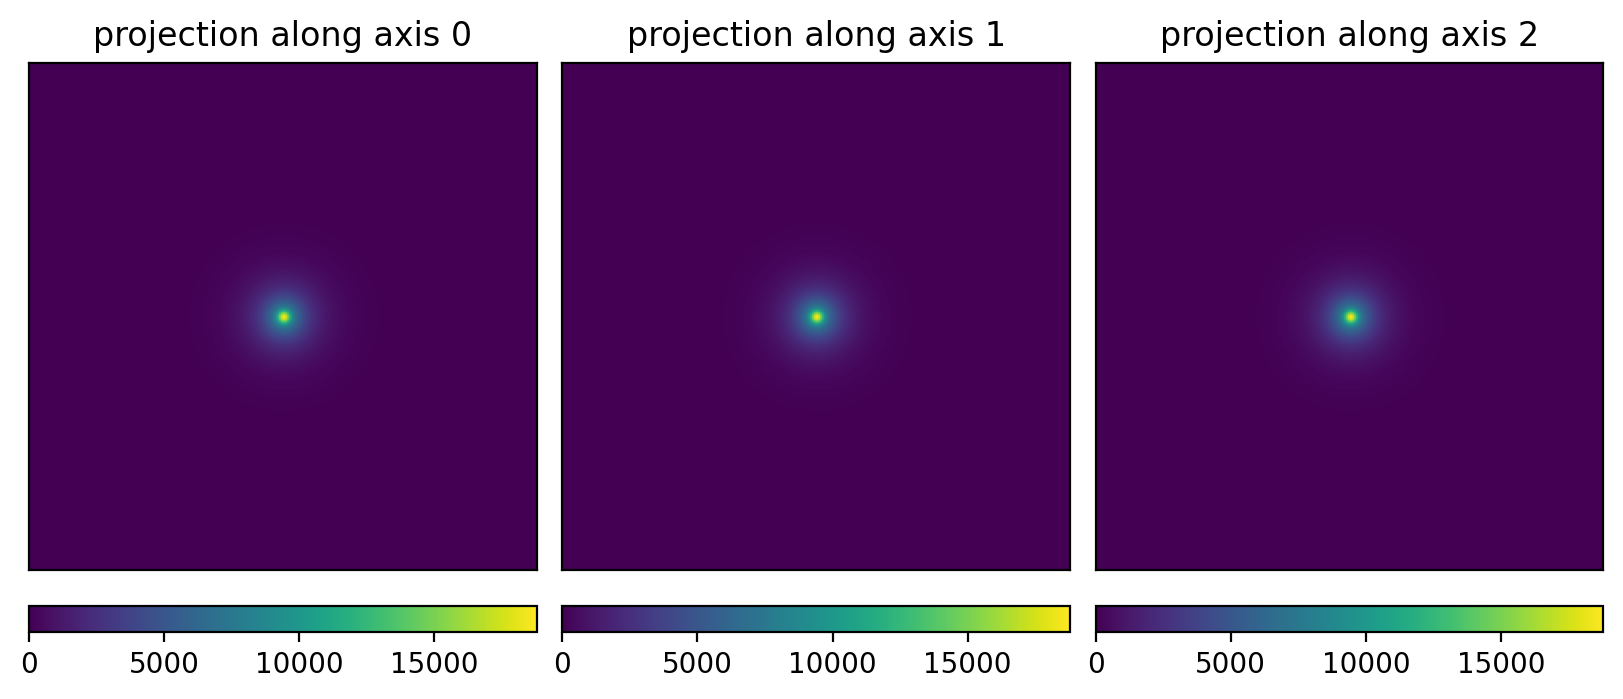

In [83]:
plot3d(torch.abs((V_gemmi)))

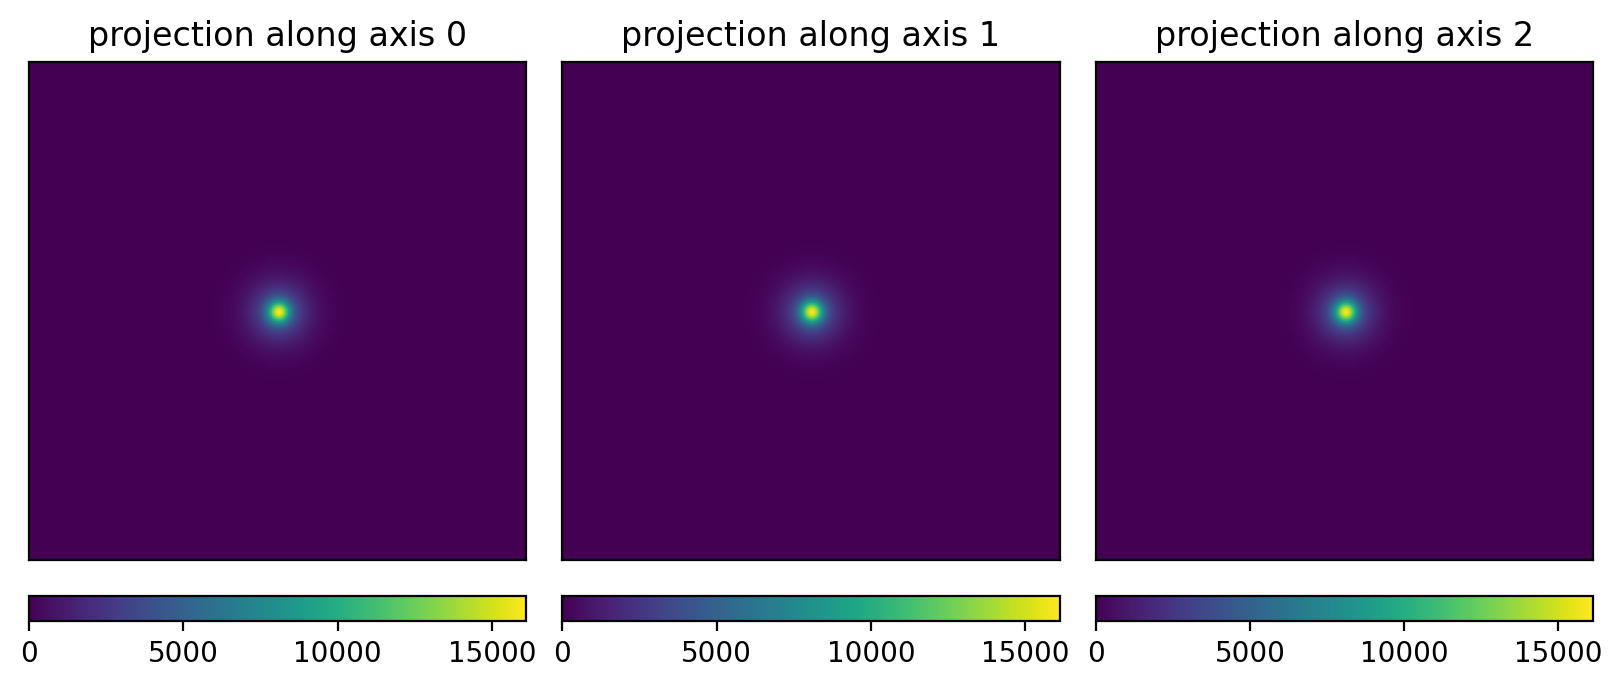

In [84]:
plot3d(torch.abs((V_gemmi_custom)))

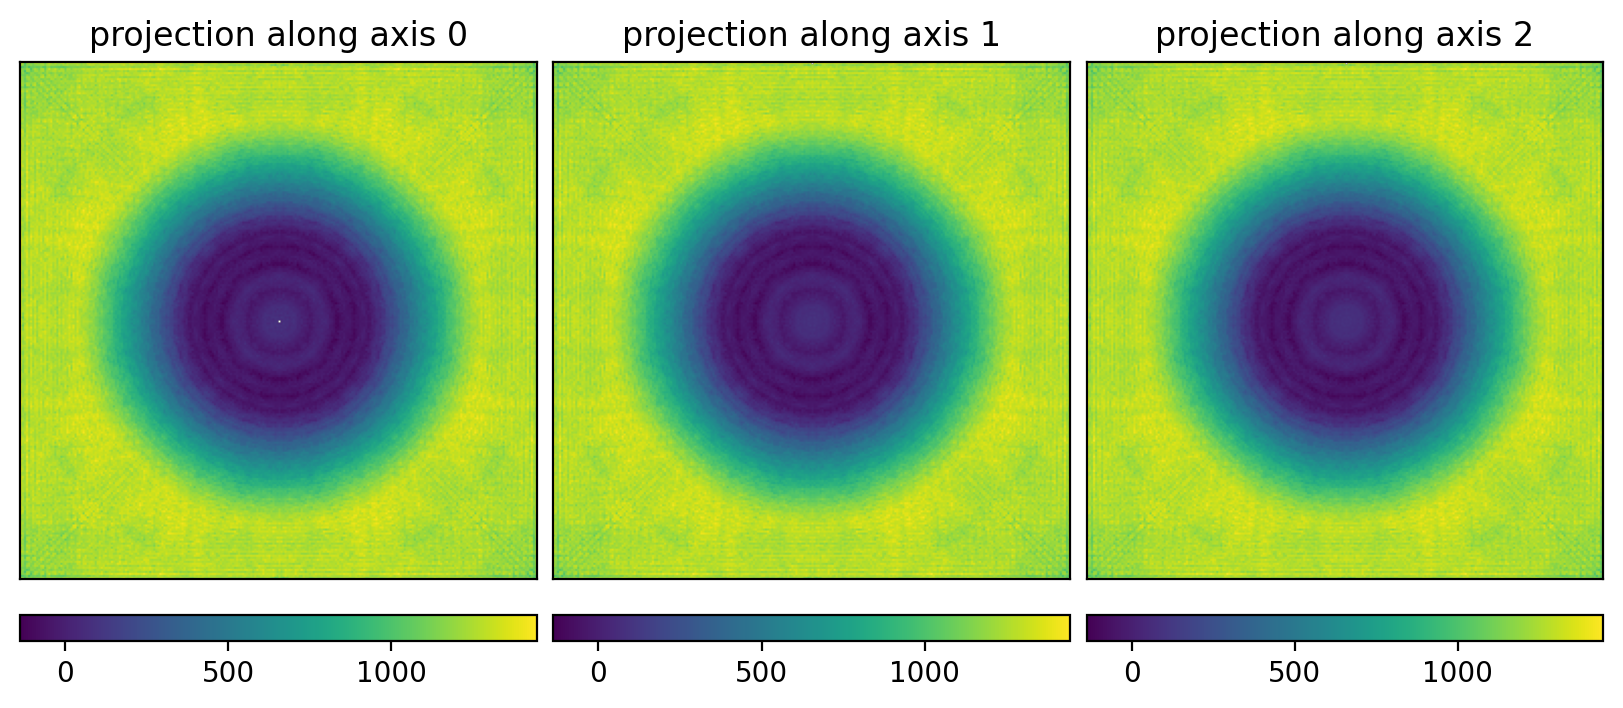

In [66]:
plot3d(torch.log(torch.abs(fftn(V_gemmi_custom)) / torch.abs(fftn(V_gemmi))))

In [67]:
diff = torch.abs(fftn(V_gemmi_custom)) / torch.abs(fftn(V_gemmi))
radial_avg = radial_profile_3d(diff)

In [68]:
radial_avg_custom = radial_profile_3d(torch.abs(fftn(V_gemmi_custom)))
radial_avg_1 = radial_profile_3d(torch.abs(fftn(V_gemmi)))

(0.0, 5.0)

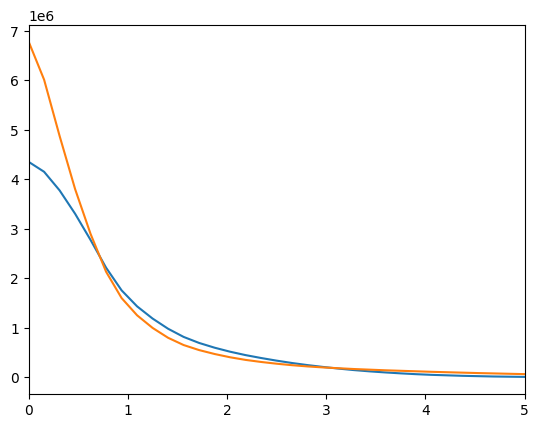

In [85]:
ln = len(radial_avg)
k = torch.arange(0, ln) * dk
plt.plot(k, radial_avg_custom)
plt.plot(k, radial_avg_1)
plt.xlim([0, 5])

(0.0, 2.0)

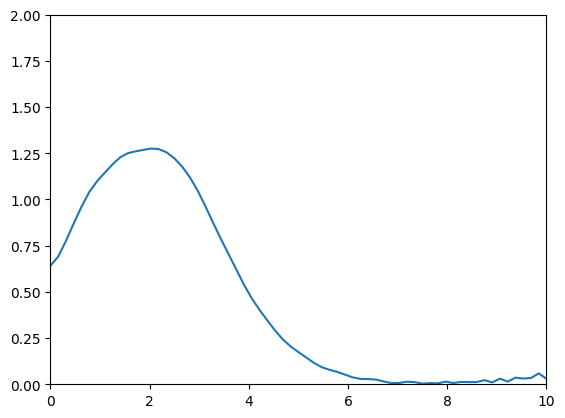

In [73]:
ln = len(radial_avg)
k = torch.arange(0, ln) * dk
plt.plot(k, radial_avg)
plt.xlim([0, 10])
plt.ylim([0, 2])